In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

In [3]:
df=pd.read_csv("/content/toxicity_en.csv")


In [4]:
df

,text,is_toxic
0,"Elon Musk is a piece of shit, greedy capitalis...",Toxic
1,The senile credit card shrill from Delaware ne...,Toxic
2,He does that a lot -- makes everyone look good...,Toxic
3,F*ck Lizzo,Toxic
4,Epstein and trump were best buds!!! Pedophiles...,Toxic
...,...,...
995,My maternal abuelita taught me how to make pla...,Not Toxic
996,Funnily enough I was looking online last week ...,Not Toxic
997,I can't bear how nice this is.\n \n I guess it...,Not Toxic
998,Going to buy a share of Tesla just to ensure i...,Not Toxic


In [5]:
text=df.text

In [6]:
text

,text
0,"Elon Musk is a piece of shit, greedy capitalis..."
1,The senile credit card shrill from Delaware ne...
2,He does that a lot -- makes everyone look good...
3,F*ck Lizzo
4,Epstein and trump were best buds!!! Pedophiles...
...,...
995,My maternal abuelita taught me how to make pla...
996,Funnily enough I was looking online last week ...
997,I can't bear how nice this is.\n \n I guess it...
998,Going to buy a share of Tesla just to ensure i...


In [7]:
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [8]:
df.dtypes

,0
text,object
is_toxic,object


In [9]:
df.head()

,text,is_toxic
0,"Elon Musk is a piece of shit, greedy capitalis...",Toxic
1,The senile credit card shrill from Delaware ne...,Toxic
2,He does that a lot -- makes everyone look good...,Toxic
3,F*ck Lizzo,Toxic
4,Epstein and trump were best buds!!! Pedophiles...,Toxic


In [10]:
df.tail()

,text,is_toxic
995,My maternal abuelita taught me how to make pla...,Not Toxic
996,Funnily enough I was looking online last week ...,Not Toxic
997,I can't bear how nice this is.\n \n I guess it...,Not Toxic
998,Going to buy a share of Tesla just to ensure i...,Not Toxic
999,I only saw a couple of these throughout the mo...,Not Toxic


In [11]:
df.isna().sum()

,0
text,0
is_toxic,0


In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
tar=df['is_toxic'].value_counts()

<BarContainer object of 2 artists>

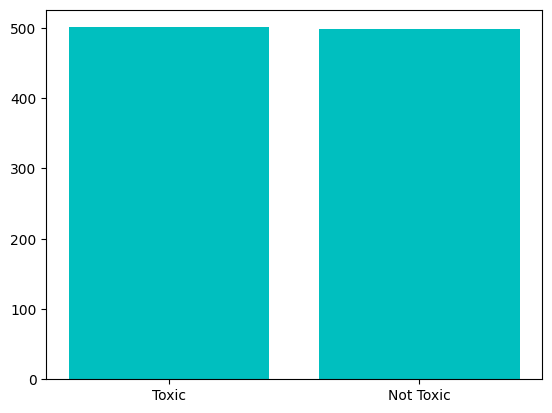

In [14]:
plt.bar(tar.index,tar.values,color='c')

In [15]:
df['is_toxic'].value_counts()

,count
is_toxic,
Toxic,501
Not Toxic,499


In [16]:
df['is_toxic']=df['is_toxic'].map({'Toxic': 1,'Not Toxic' : 0})

In [17]:
df['is_toxic'].value_counts()

,count
is_toxic,
1,501
0,499


In [18]:
from nltk.tokenize import TweetTokenizer
tk=TweetTokenizer()
tweets=text.apply(lambda x:tk.tokenize(x)).apply(lambda x:" ".join(x))
tweets

,text
0,"Elon Musk is a piece of shit , greedy capitali..."
1,The senile credit card shrill from Delaware ne...
2,He does that a lot - - makes everyone look goo...
3,F * ck Lizzo
4,Epstein and trump were best buds ! ! ! Pedophi...
...,...
995,My maternal abuelita taught me how to make pla...
996,Funnily enough I was looking online last week ...
997,I can't bear how nice this is . I guess its be...
998,Going to buy a share of Tesla just to ensure i...


In [19]:
tweets=tweets.replace('[^a-zA-Z0-9]',' ',regex=True)
tweets

,text
0,Elon Musk is a piece of shit greedy capitali...
1,The senile credit card shrill from Delaware ne...
2,He does that a lot makes everyone look goo...
3,F ck Lizzo
4,Epstein and trump were best buds Pedophi...
...,...
995,My maternal abuelita taught me how to make pla...
996,Funnily enough I was looking online last week ...
997,I can t bear how nice this is I guess its be...
998,Going to buy a share of Tesla just to ensure i...


In [20]:
tweets=tweets.apply(lambda x:" ".join([w for w in tk.tokenize(x) if len(w)>=3]))
tweets


,text
0,Elon Musk piece shit greedy capitalist who exp...
1,The senile credit card shrill from Delaware ne...
2,does that lot makes everyone look good but him...
3,Lizzo
4,Epstein and trump were best buds Pedophiles wh...
...,...
995,maternal abuelita taught how make plantain emp...
996,Funnily enough was looking online last week an...
997,can bear how nice this guess its bearnessities...
998,Going buy share Tesla just ensure starts going...


In [21]:
from nltk.stem import PorterStemmer
data=PorterStemmer()
tweets=tweets.apply(lambda x:[data.stem(i.lower()) for i in tk.tokenize(x)]).apply(lambda x:" ".join(x))
tweets

,text
0,elon musk piec shit greedi capitalist who expl...
1,the senil credit card shrill from delawar need...
2,doe that lot make everyon look good but him gu...
3,lizzo
4,epstein and trump were best bud pedophil who p...
...,...
995,matern abuelita taught how make plantain empan...
996,funnili enough wa look onlin last week and won...
997,can bear how nice thi guess it bearness see se...
998,go buy share tesla just ensur start go back down


In [22]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
from nltk.corpus import stopwords
word=stopwords.words('english')
tweets=tweets.apply(lambda x:[i for i in tk.tokenize(x) if i not in word]).apply(lambda x:" ".join(x))
tweets

,text
0,elon musk piec shit greedi capitalist exploit ...
1,senil credit card shrill delawar need resign
2,doe lot make everyon look good guess also prob...
3,lizzo
4,epstein trump best bud pedophil play togeth
...,...
995,matern abuelita taught make plantain empanada ...
996,funnili enough wa look onlin last week wonder ...
997,bear nice thi guess bearness see self
998,go buy share tesla ensur start go back


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
vc=TfidfVectorizer()
train_data=vc.fit_transform(tweets)
train_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12199 stored elements and shape (1000, 3860)>

In [25]:
y=df['is_toxic'].values
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(train_data,y,test_size=0.30,random_state=42)

In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)
y_predknn=knn.predict(x_test)
y_predknn

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1])

In [34]:
from sklearn.metrics import accuracy_score

In [35]:
scoreknn=accuracy_score(y_test,y_predknn)
scoreknn

0.7266666666666667

In [32]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(x_train,y_train)
y_prednb=nb.predict(x_test)
y_prednb

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1])

In [33]:
scorenb=accuracy_score(y_test,y_prednb)
scorenb

0.8866666666666667

In [28]:
from sklearn.svm import SVC
sv=SVC()
sv.fit(x_train,y_train)
y_predsvm=sv.predict(x_test)
y_predsvm

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1])

In [30]:
score=accuracy_score(y_test,y_predsvm)
score

0.8833333333333333

In [36]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_preddt=dt.predict(x_test)
y_preddt

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1])

In [38]:
scoretree=accuracy_score(y_test,y_preddt)
scoretree

0.7466666666666667

Text(0.5, 1.0, 'Model Comparison')

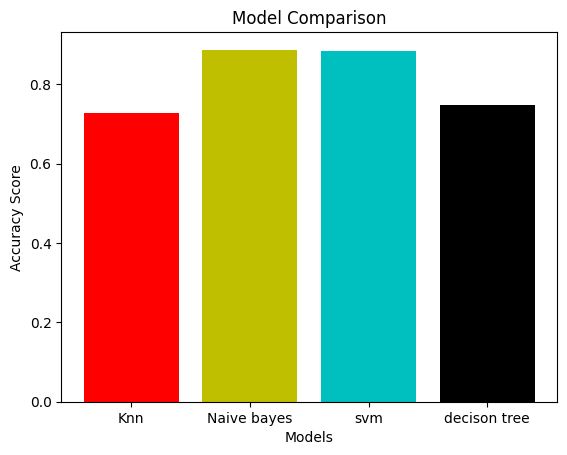

In [40]:
scores=[scoreknn,scorenb,score,scoretree]
model=['Knn',"Naive bayes","svm","decison tree"]
plt.bar(model,scores,color=['r','y','c','k'])
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Model Comparison")